# WCDA Weekly Analysis

这个 notebook 用于 Mrk 421 的 WCDA weekly light curve 基础时序分析。
当前只看真实观测数据上的 light curve、Morlet CWT 和 WWZ，不做模拟光变、Monte Carlo 或显著性检验。

旧版 notebook 已归档到 `notebooks/archive/`，这里保留的是更适合顺着阅读的主流程版本。

## 1. 导入依赖与路径定位

In [1]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pycwt as wavelet
from scipy.signal import find_peaks
from libwwz import wwt


def locate_project_root(markers=("data", "notebooks", "src")):
    # 从当前工作目录向上回溯，找到仓库根目录。
    # 这样 notebook 不依赖你是从哪里启动的。
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(f"Could not locate project root from {cwd}")


PROJECT_ROOT = locate_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks"

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /mnt/mydisk/server/projects/QPO


## 2. 数据加载

先读取 WCDA weekly CSV，并确认列名、行数和时间范围。

In [2]:
wcda_candidates = [
    DATA_ROOT / 'raw' / 'wcda' / 'LHAASO-WCDA_Mrk421_2021-03-08_2025-11-06_week(1).csv',
    *sorted((DATA_ROOT / 'raw' / 'wcda').glob('*.csv')),
]
WCDA_CSV = next((path for path in wcda_candidates if path.exists()), None)
if WCDA_CSV is None:
    raise FileNotFoundError('Could not locate the WCDA weekly CSV under data/raw/wcda/.')

# 这里保留 comment="#"，因为文件前面通常带有少量说明性注释行。
df_wcda_raw = pd.read_csv(WCDA_CSV, comment='#')
df_wcda_raw.columns = [col.strip() for col in df_wcda_raw.columns]

print('WCDA_CSV =', WCDA_CSV)
print('rows =', len(df_wcda_raw))
print('columns =', list(df_wcda_raw.columns))
print('MJD range =', float(df_wcda_raw['mjd'].min()), '->', float(df_wcda_raw['mjd'].max()))
df_wcda_raw.head()

WCDA_CSV = /mnt/mydisk/server/projects/QPO/data/raw/wcda/LHAASO-WCDA_Mrk421_2021-03-08_2025-11-06_week(1).csv
rows = 244
columns = ['name', 'mjd', 'n_on', 'n_bkg', 'n_off', 'tobs']
MJD range = 59284.33328206009 -> 60983.58347916683


,name,mjd,n_on,n_bkg,n_off,tobs
0,2021-03-08_2021-03-14,59284.333282,"[29993.0, 3587.0, 492.0, 49.0, 12.0, 5.0, 0.0]","[29243.652722059553, 3363.8779377954856, 343.6...","[974127581.0722984, 111906053.63591918, 114144...",139426.0
1,2021-03-15_2021-03-21,59291.166555,"[29885.0, 3659.0, 523.0, 72.0, 18.0, 2.0, 1.0]","[29258.75759635251, 3358.7003245244196, 339.50...","[878458366.141048, 100491722.87936412, 1013273...",145651.9
2,2021-03-22_2021-03-28,59298.166398,"[40709.0, 4976.0, 627.0, 55.0, 12.0, 2.0, 0.0]","[40203.975175464184, 4585.391972246652, 466.72...","[1235054100.632157, 140838374.34434447, 143470...",188838.4
3,2021-03-29_2021-04-04,59305.166138,"[30616.0, 3736.0, 461.0, 39.0, 8.0, 1.0, 0.0]","[30120.583690972515, 3413.321162371668, 347.07...","[912543015.7808521, 103498088.62900041, 105278...",134297.8
4,2021-04-05_2021-04-11,59312.166027,"[39576.0, 4656.0, 557.0, 49.0, 14.0, 1.0, 0.0]","[38992.98117386203, 4419.974325696912, 450.995...","[1260325153.0542603, 142466304.81074297, 14513...",183362.0


## 3. 数据预处理

把 `n_on`、`n_bkg`、`n_off` 从字符串列表转成数组，计算 excess rate 和误差。

In [3]:
df_wcda = df_wcda_raw.copy()
# `n_on` / `n_bkg` / `n_off` 在 CSV 里是列表字符串，先转成真正的数组，后面才能逐 bin 计算。
for col in ['n_on', 'n_bkg', 'n_off']:
    df_wcda[col] = df_wcda[col].apply(ast.literal_eval).apply(lambda values: np.asarray(values, dtype=float))

def compute_wcda_products(row):
    n_on = row['n_on']
    n_bkg = row['n_bkg']
    n_off = row['n_off']
    tobs = float(row['tobs'])

    # excess_counts 是每个 nhits bin 的 (n_on - n_bkg) 之和。
    excess = n_on - n_bkg
    excess_counts = float(np.sum(excess))
    flux_excess = excess_counts / tobs

    # 用一个简单的 Poisson 误差近似给出 flux_err，便于 WWZ 使用。
    alpha = np.divide(n_bkg, n_off, out=np.zeros_like(n_bkg, dtype=float), where=n_off > 0)
    sigma_bin = np.sqrt(np.clip(n_on + np.square(alpha) * n_off, 0.0, None))
    flux_excess_err = float(np.sqrt(np.sum(np.square(sigma_bin))) / tobs)

    return pd.Series({
        'excess_counts': excess_counts,
        'flux_excess': flux_excess,
        'flux_excess_err': flux_excess_err,
        'n_on_tot': float(np.sum(n_on)),
        'n_bkg_tot': float(np.sum(n_bkg)),
    })

df_wcda = df_wcda.join(df_wcda.apply(compute_wcda_products, axis=1))
df_wcda = df_wcda.sort_values('mjd').reset_index(drop=True)

# 只保留数值完整、曝光时间正常、误差为正的点。
valid_mask = (
    np.isfinite(df_wcda['mjd'])
    & np.isfinite(df_wcda['flux_excess'])
    & np.isfinite(df_wcda['flux_excess_err'])
    & (df_wcda['tobs'] > 0)
    & (df_wcda['flux_excess_err'] > 0)
)
df_wcda = df_wcda.loc[valid_mask].copy().reset_index(drop=True)

t_wcda = df_wcda['mjd'].to_numpy(dtype=float)
flux_wcda = df_wcda['flux_excess'].to_numpy(dtype=float)
flux_err_wcda = df_wcda['flux_excess_err'].to_numpy(dtype=float)

print('usable points =', len(df_wcda))
print('final MJD range =', float(t_wcda.min()), '->', float(t_wcda.max()))
print('median cadence [day] =', float(np.median(np.diff(t_wcda))))
df_wcda[['name', 'mjd', 'excess_counts', 'flux_excess', 'flux_excess_err']].head()

usable points = 244
final MJD range = 59284.33328206009 -> 60983.58347916683
median cadence [day] = 6.999996295890014


,name,mjd,excess_counts,flux_excess,flux_excess_err
0,2021-03-08_2021-03-14,59284.333282,1158.735212,0.008311,0.001325
1,2021-03-15_2021-03-21,59291.166555,1175.008720,0.008067,0.001269
2,2021-03-22_2021-03-28,59298.166398,1085.918223,0.005751,0.001140
3,2021-03-29_2021-04-04,59305.166138,950.994148,0.007081,0.001390
4,2021-04-05_2021-04-11,59312.166027,951.315642,0.005188,0.001155


## 4. 光变可视化

先画出原始 weekly 光变，方便对时间覆盖和数据波动有一个直观印象。

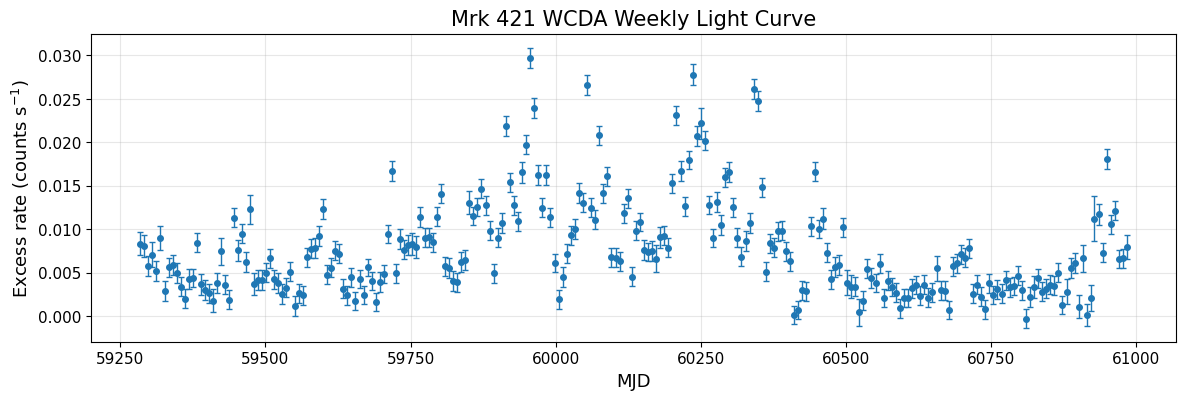

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.errorbar(
    t_wcda,
    flux_wcda,
    yerr=flux_err_wcda,
    fmt='o',
    ms=4,
    capsize=2,
    elinewidth=1,
)
ax.set_xlabel('MJD')
ax.set_ylabel('Excess rate (counts s$^{-1}$)')
ax.set_title('Mrk 421 WCDA Weekly Light Curve')
plt.show()

## 5. CWT 分析

这里用 Morlet 小波看时-频局部结构，并提取 Global Wavelet Spectrum 作为全局参考。

In [5]:
def standardize_flux(flux):
    # 小波变换前先做标准化，避免均值和量纲影响 power 的比较。
    flux = np.asarray(flux, dtype=float)
    flux = flux - np.nanmean(flux)
    std = np.nanstd(flux)
    if not np.isfinite(std) or std == 0:
        raise ValueError("Flux standard deviation is zero or non-finite.")
    return flux / std


def run_cwt(t_mjd, flux, *, dj=1/12, period_min=50.0, period_max=600.0, mother=None):
    # 统一封装 CWT，方便 WCDA / Fermi 两本 notebook 使用同一套参数。
    t_mjd = np.asarray(t_mjd, dtype=float)
    flux = np.asarray(flux, dtype=float)
    dt = float(np.median(np.diff(t_mjd)))
    if mother is None:
        mother = wavelet.Morlet(6)
    s0 = 2.0 * dt
    J = int(np.log2(len(flux) * dt / s0) / dj)

    y = standardize_flux(flux)
    wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(
        y,
        dt,
        dj=dj,
        s0=s0,
        J=J,
        wavelet=mother,
    )
    power = np.abs(wave) ** 2
    period = 1.0 / freqs
    gws = np.nanmean(power, axis=1)
    mask_period = (period >= period_min) & (period <= period_max)

    return {
        "dt": dt,
        "dj": dj,
        "mother": mother,
        "s0": s0,
        "J": J,
        "power": power,
        "period": period,
        "coi": np.asarray(coi, dtype=float),
        "gws": gws,
        "mask_period": mask_period,
        "period_min": period_min,
        "period_max": period_max,
    }


def plot_cwt_summary(t_mjd, flux, flux_err, result, *, lc_title, flux_label):
    # 左边画光变，中间画时频图，右边画 GWS，便于一屏对照。
    t_mjd = np.asarray(t_mjd, dtype=float)
    flux = np.asarray(flux, dtype=float)
    flux_err = None if flux_err is None else np.asarray(flux_err, dtype=float)

    period = result["period"]
    mask_period = result["mask_period"]
    power = result["power"]
    coi = result["coi"]
    gws = result["gws"]
    period_min = result["period_min"]
    period_max = result["period_max"]
    T, P = np.meshgrid(t_mjd, period)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 4.8),
        gridspec_kw={"width_ratios": [1.45, 2.5, 1.0]},
        constrained_layout=True,
    )

    ax_lc, ax_map, ax_gws = axes
    if flux_err is not None:
        ax_lc.errorbar(t_mjd, flux, yerr=flux_err, fmt="o", ms=4, capsize=2, elinewidth=1)
    else:
        ax_lc.plot(t_mjd, flux, "o-", ms=4, lw=1.2)
    ax_lc.set_title(lc_title)
    ax_lc.set_xlabel("MJD")
    ax_lc.set_ylabel(flux_label)

    im = ax_map.contourf(
        T[mask_period, :],
        P[mask_period, :],
        power[mask_period, :],
        levels=50,
        cmap="magma",
        extend="both",
    )
    # COI 外的区域更容易受边界效应影响，因此这里把它标出来。
    coi_clip = np.clip(coi, period_min, period_max)
    ax_map.fill_between(
        t_mjd,
        period_max,
        coi_clip,
        where=coi_clip <= period_max,
        color="white",
        alpha=0.5,
        hatch="/",
        edgecolor="0.7",
        linewidth=0.0,
    )
    ax_map.plot(t_mjd, coi_clip, color="white", lw=1.5, label="COI")
    ax_map.set_yscale("log")
    ax_map.set_ylim(period_min, period_max)
    ax_map.set_xlabel("MJD")
    ax_map.set_ylabel("Period (day)")
    ax_map.set_title("CWT Power Spectrum (Morlet)")
    ax_map.legend(loc="upper right")
    cbar = fig.colorbar(im, ax=ax_map, pad=0.02)
    cbar.set_label("Power")

    ax_gws.plot(gws, period, color="black", lw=1.6)
    ax_gws.set_xscale("log")
    ax_gws.set_yscale("log")
    ax_gws.set_ylim(period_min, period_max)
    ax_gws.set_xlabel("Global Wavelet Power")
    ax_gws.set_title("Global Wavelet Spectrum")
    plt.setp(ax_gws.get_yticklabels(), visible=False)

    return fig, axes


def clean_and_merge_weighted(t, y, yerr):
    # WWZ 之前先清洗、排序，并把重复时间点合并掉，避免数值问题。
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    mask = np.isfinite(t) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    t, y, yerr = t[mask], y[mask], yerr[mask]

    order = np.argsort(t)
    t, y, yerr = t[order], y[order], yerr[order]

    uniq_t, idx_start = np.unique(t, return_index=True)
    if len(uniq_t) == len(t):
        return t, y, yerr

    y_new = np.empty_like(uniq_t, dtype=float)
    e_new = np.empty_like(uniq_t, dtype=float)
    for k, t0 in enumerate(uniq_t):
        i0 = idx_start[k]
        i1 = idx_start[k + 1] if (k + 1 < len(uniq_t)) else len(t)
        w = 1.0 / np.square(yerr[i0:i1])
        y_new[k] = np.sum(w * y[i0:i1]) / np.sum(w)
        e_new[k] = np.sqrt(1.0 / np.sum(w))
    return uniq_t, y_new, e_new


def run_wwz(t_mjd, flux, flux_err, *, period_min=50.0, period_max=500.0, time_divisions=250, decay_constant=0.0125):
    # 把 WWZ 计算流程封装起来，后面 Fermi notebook 直接复用同一套逻辑。
    t, y, yerr = clean_and_merge_weighted(t_mjd, flux, flux_err)
    t_span = float(t.max() - t.min())
    freq_low = 1.0 / period_max
    freq_high = 1.0 / period_min
    freq_step = 0.05 / t_span

    tau_mat, freq_mat, wwz_mat, amp_mat, coef_mat, neff_mat = wwt(
        timestamps=t.astype(float),
        magnitudes=y.astype(float),
        time_divisions=time_divisions,
        freq_params=[freq_low, freq_high, freq_step, True],
        decay_constant=decay_constant,
        method="linear",
        parallel=True,
    )

    period_mat = 1.0 / freq_mat
    ridge_idx = np.argmax(wwz_mat, axis=1)
    ridge_tau = tau_mat[:, 0]
    ridge_period = period_mat[np.arange(len(ridge_idx)), ridge_idx]
    ridge_power = wwz_mat[np.arange(len(ridge_idx)), ridge_idx]
    global_wwz = np.nanmean(wwz_mat, axis=0)
    period_axis = 1.0 / freq_mat[0, :]

    return {
        "t": t,
        "y": y,
        "yerr": yerr,
        "t_span": t_span,
        "freq_low": freq_low,
        "freq_high": freq_high,
        "freq_step": freq_step,
        "time_divisions": time_divisions,
        "decay_constant": decay_constant,
        "tau_mat": tau_mat,
        "freq_mat": freq_mat,
        "period_mat": period_mat,
        "wwz_mat": wwz_mat,
        "ridge_tau": ridge_tau,
        "ridge_period": ridge_period,
        "ridge_power": ridge_power,
        "global_wwz": global_wwz,
        "period_axis": period_axis,
        "period_min": period_min,
        "period_max": period_max,
    }


def plot_wwz_summary(result, *, lc_title, flux_label):
    # 这里和 CWT 一样：左边是光变，中间是 WWZ 时频图，右边是全局平均谱。
    t = result["t"]
    y = result["y"]
    yerr = result["yerr"]
    period_min = result["period_min"]
    period_max = result["period_max"]

    tau_plot = result["tau_mat"][:, 0]
    period_mat = result["period_mat"]
    wwz_mat = result["wwz_mat"]
    sort_idx = np.argsort(period_mat[0, :])
    p_axis = period_mat[0, sort_idx]
    wwz_plot = wwz_mat[:, sort_idx]

    period_axis = result["period_axis"]
    global_wwz = result["global_wwz"]
    period_sort = np.argsort(period_axis)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 4.8),
        gridspec_kw={"width_ratios": [1.45, 2.5, 1.0]},
        constrained_layout=True,
    )
    ax_lc, ax_map, ax_gwwz = axes

    ax_lc.errorbar(t, y, yerr=yerr, fmt="o", ms=4, capsize=2, elinewidth=1)
    ax_lc.set_title(lc_title)
    ax_lc.set_xlabel("MJD")
    ax_lc.set_ylabel(flux_label)

    mesh = ax_map.pcolormesh(tau_plot, p_axis, wwz_plot.T, shading="auto", cmap="viridis")
    ax_map.plot(result["ridge_tau"], result["ridge_period"], color="black", lw=1.5, alpha=0.9, label="ridge")
    ax_map.set_ylim(period_min, period_max)
    ax_map.set_xlabel("MJD")
    ax_map.set_ylabel("Period (day)")
    ax_map.set_title("WWZ Time-Period Map")
    ax_map.legend(loc="upper right")
    cbar = fig.colorbar(mesh, ax=ax_map, pad=0.02)
    cbar.set_label("WWZ power")

    ax_gwwz.plot(global_wwz[period_sort], period_axis[period_sort], color="black", lw=1.6)
    ax_gwwz.set_xscale("log")
    ax_gwwz.set_yscale("log")
    ax_gwwz.set_ylim(period_min, period_max)
    ax_gwwz.set_xlabel("Mean WWZ power")
    ax_gwwz.set_title("Global WWZ Spectrum")
    plt.setp(ax_gwwz.get_yticklabels(), visible=False)

    return fig, axes


def top_period_candidates(period, spectrum, *, topk=5):
    # 只做“候选周期”摘要，不做显著性判断。
    period = np.asarray(period, dtype=float)
    spectrum = np.asarray(spectrum, dtype=float)
    mask = np.isfinite(period) & np.isfinite(spectrum)
    period = period[mask]
    spectrum = spectrum[mask]
    if len(period) < 3:
        return pd.DataFrame(columns=["period_day", "power"])

    peaks, _ = find_peaks(spectrum)
    if len(peaks) == 0:
        peaks = np.argsort(spectrum)[-min(topk, len(spectrum)):]
    order = peaks[np.argsort(spectrum[peaks])[::-1][:topk]]
    return pd.DataFrame({
        "period_day": period[order],
        "power": spectrum[order],
    }).sort_values("power", ascending=False).reset_index(drop=True)

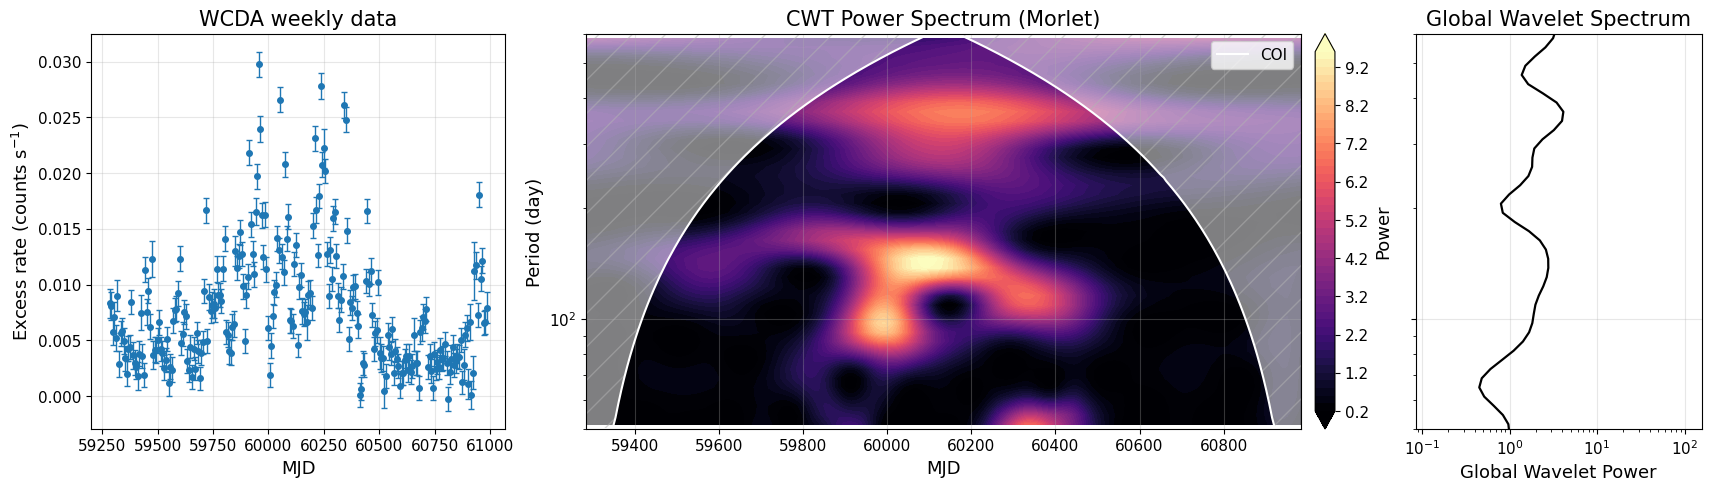

,period_day,power
0,873.656311,24.121404
1,367.327230,4.124207
2,137.592247,2.775932
3,48.646205,0.996626


In [6]:
wcda_cwt = run_cwt(t_wcda, flux_wcda, period_min=50.0, period_max=600.0)
fig, axes = plot_cwt_summary(
    t_wcda,
    flux_wcda,
    flux_err_wcda,
    wcda_cwt,
    lc_title='WCDA weekly data',
    flux_label='Excess rate (counts s$^{-1}$)',
)
plt.show()

# 这里列出的只是“候选周期峰”，不是显著性结论。
wcda_cwt_candidates = top_period_candidates(wcda_cwt['period'], wcda_cwt['gws'], topk=5)
wcda_cwt_candidates

## 6. WWZ 分析

WWZ 更适合不规则或带误差的观测序列，这里作为 CWT 的互证工具。

*** Starting Weighted Wavelet Z-transform ***

adjusted time_divisions to:  244
Pseudo sample frequency (median) is  0.143
largest tau window is  6.993
10.73 seconds has passed to complete Weighted Wavelet Z-transform 



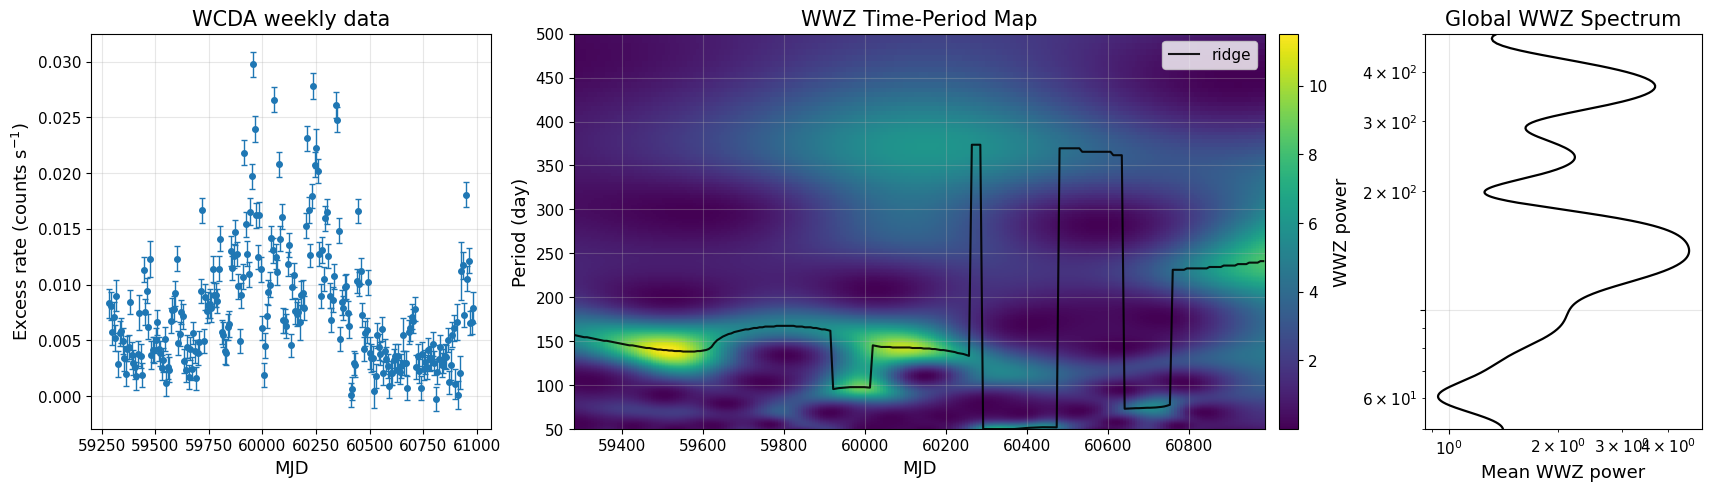

,period_day,power
0,141.034165,4.579150
1,369.522682,3.692027
2,242.802043,2.220125


In [7]:
wcda_wwz = run_wwz(
    t_wcda,
    flux_wcda,
    flux_err_wcda,
    period_min=50.0,
    period_max=500.0,
    time_divisions=250,
    decay_constant=0.0125,
)
fig, axes = plot_wwz_summary(
    wcda_wwz,
    lc_title='WCDA weekly data',
    flux_label='Excess rate (counts s$^{-1}$)',
)
plt.show()

# 这里列出的只是“候选周期峰”，不是显著性结论。
wcda_wwz_candidates = top_period_candidates(wcda_wwz['period_axis'], wcda_wwz['global_wwz'], topk=5)
wcda_wwz_candidates

## 7. 简要结果说明

- 这次真实数据分析中，WCDA 的 CWT / GWS 在约 **140 d**、**370 d** 一带都给出了可见增强；同时还出现了一个更长的 **~870 d** 宽尺度结构，但它已经接近总时间跨度，解读时需要特别注意 COI 与有限基线效应。
- WCDA 的 WWZ 时间平均谱与 ridge 结果同样强调了约 **140 d** 和 **370 d** 左右的候选尺度，并在 **~240 d** 一带给出次级增强。
- 这些尺度目前只代表观测上的候选时频结构，适合作为下一步跨波段比较和后续统计检验的重点区间。
- 当前 notebook **未进行模拟、显著性阈值、pre-trial / post-trial、Monte Carlo 或 Emmanoulopoulos 检验**，因此这里不能把上述结构表述为显著周期检测结论。